In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load dataset
# wdbc.data does not have headers, so we define them
columns = ["ID", "Diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data = pd.read_csv("wdbc.data", header=None, names=columns)

In [3]:
# 2. Prepare features and target
X = data.drop(["ID", "Diagnosis"], axis=1)
y = data["Diagnosis"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# --- 4. Pipeline with PCA + XGBoost ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42))
])

In [ ]:
# 6. Hyperparameter grid
param_grid = {
    "pca__n_components": [5, 10, 15, 20, 25, 30],
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.1, 0.2],
    "clf__max_depth": [3, 5, 7],
    "clf__gamma": [0, 0.1, 0.5],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

In [11]:
# 6. GridSearchCV (accuracy only)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",   # only accuracy
    refit=True,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 1944 candidates, totalling 9720 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'clf__colsample_bytree': [0.8, 1.0], 'clf__gamma': [0, 0.1, ...], 'clf__learning_rate': [0.01, 0.1, ...], 'clf__max_depth': [3, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [15]:
# --- 7. Best model & top 5 hyperparameters ---
best_model = grid.best_estimator_
results = pd.DataFrame(grid.cv_results_)
top5 = results.sort_values(by="mean_test_score", ascending=False).head(5)

print("Top 5 Hyperparameter Trials (with PCA):")
print(top5[[
    "param_pca__n_components",
    "param_clf__n_estimators",
    "param_clf__learning_rate",
    "param_clf__max_depth",
    "param_clf__gamma",
    "mean_test_score"
]].rename(columns={
    "pca__n_components": "n_components",
    "param_clf__n_estimators": "n_estimators",
    "param_clf__learning_rate": "learning_rate",
    "param_clf__max_depth": "max_depth",
    "param_clf__gamma": "gamma",
    "mean_test_score": "Accuracy"
}))

Top 5 Hyperparameter Trials (with PCA):
      param_pca__n_components  n_estimators  learning_rate  max_depth  gamma  \
1183                       10           200            0.1          7    0.0   
1203                       20           100            0.2          3    0.0   
927                        20           200            0.2          5    0.5   
915                        20           100            0.2          5    0.5   
1197                       20            50            0.2          3    0.0   

      Accuracy  
1183  0.973626  
1203  0.973626  
927   0.973626  
915   0.973626  
1197  0.971429  


In [16]:
print("\nBest Hyperparameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Best Hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0.5, 'clf__learning_rate': 0.2, 'clf__max_depth': 5, 'clf__n_estimators': 100, 'clf__subsample': 0.8, 'pca__n_components': 20}
Best CV Accuracy: 0.9736263736263737


In [18]:
# --- 8. Test set evaluation ---
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred))


Test Accuracy: 0.9649122807017544
Test F1 Score: 0.9512195121951219
Test Precision: 0.975
Test Recall: 0.9285714285714286
Test ROC AUC: 0.9573412698412699


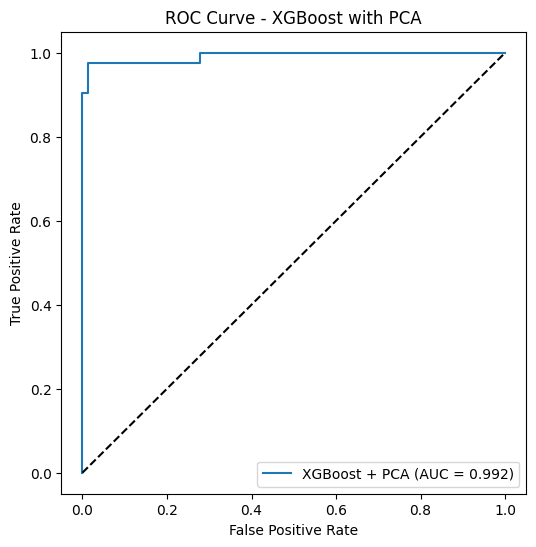

In [20]:
# --- 9. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"XGBoost + PCA (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost with PCA")
plt.legend()
plt.show()

/tmp/ipykernel_12029/2643072674.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")


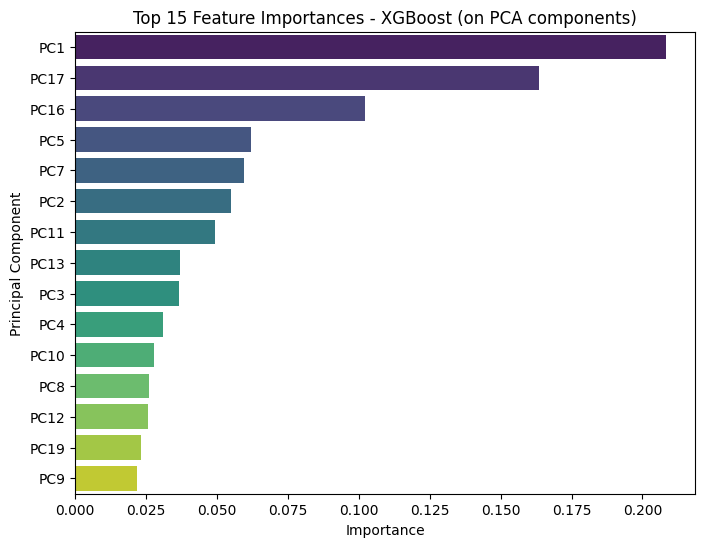

In [22]:
# --- 10. Feature Importances (XGBoost + PCA) ---
importances = best_model.named_steps["clf"].feature_importances_

# Number of components actually used
n_components = best_model.named_steps["pca"].n_components_

# Create names for PCA features
pca_features = [f"PC{i+1}" for i in range(n_components)]

feat_imp = pd.Series(importances, index=pca_features).sort_values(ascending=False)[:15]

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="viridis")
plt.title("Top 15 Feature Importances - XGBoost (on PCA components)")
plt.xlabel("Importance")
plt.ylabel("Principal Component")
plt.show()


In [29]:

# 5-Fold CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation on the full training data
cv_acc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy")

# Print results
print("XGBoost + PCA - 5-Fold Cross-Validation Results")
for i, acc in enumerate(cv_acc, 1):
    print(f"Fold {i} Accuracy: {acc:.4f}")
print(f"Average 5-Fold CV Accuracy: {cv_acc.mean():.4f}")

XGBoost + PCA - 5-Fold Cross-Validation Results
Fold 1 Accuracy: 0.9560
Fold 2 Accuracy: 0.9780
Fold 3 Accuracy: 0.9670
Fold 4 Accuracy: 0.9780
Fold 5 Accuracy: 0.9890
Average 5-Fold CV Accuracy: 0.9736
